In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Đọc file transactions.csv
transactions = pd.read_csv("/content/drive/MyDrive/NCKH/transactions.csv")

In [ ]:
earliest_date = transactions['time'].min()
latest_date = transactions['time'].max()
print(f"Ngày giao dịch đầu tiên: {earliest_date}")
print(f"Ngày giao dịch cuối cùng: {latest_date}")

Ngày giao dịch đầu tiên: 2017-05-11 03:45:09
Ngày giao dịch cuối cùng: 2026-03-19 10:24:27


In [ ]:
transactions.head()

,tx_hash,time,address,net_flow,direction,n_inputs,n_outputs,fee_rate
0,4106937540f7ae144cb06aace98ef51a94d0622f1adac0...,2021-05-10 14:24:59,12LRDdhtCPJr3KsAg26gV2UjPJbiwj2867,-148686,sell,91,2,83.073568
1,9dae9a45446222fa017b97b7ef7b519c81ef5c30f1ecae...,2021-05-08 21:48:30,12LRDdhtCPJr3KsAg26gV2UjPJbiwj2867,148686,buy,1,1,11.057592
2,3106208ad95546a1458845e0a1404f7e77abbb6b1851a8...,2021-03-14 12:11:12,13pqLytFgx7MwLAjK6BDGfzeMqKkd6ZsCY,-6700000,sell,56,2,94.568955
3,a8762d888e7850d3dc989928777f2ecd5bfd04af31ebfc...,2021-03-14 02:59:00,13pqLytFgx7MwLAjK6BDGfzeMqKkd6ZsCY,6700000,buy,1,1,61.235828
4,f36cb0842ce328510f7ae67a3e952a59c2c33ee8435c10...,2020-09-03 21:03:31,13pqLytFgx7MwLAjK6BDGfzeMqKkd6ZsCY,-2214099,sell,23,2,108.925583


In [ ]:
transactions.columns.to_list()
# tx_hash: mã giao dịch
# time: thời điểm giao dịch
# net_flow = output - input, nếu net_flow > 0 => inflow (buy), ngược lại net_flow < 0 => outflow (sell)
# direction: nếu net_flow > 0 => inflow (buy), ngược lại net_flow < 0 => outflow (sell)
# n_inputs: số địa chỉ tham gia giao dịch ở inputs
# n_outputs: số địa chỉ tham gia giao dịch ở outputs
# fee_rate = fee / size : chi phí giao dịch

['tx_hash',
 'time',
 'address',
 'net_flow',
 'direction',
 'n_inputs',
 'n_outputs',
 'fee_rate']

In [ ]:
history = pd.read_csv("/content/drive/MyDrive/NCKH/Bitcoin_15_4_2017-14_6_2017_historical_data_coinmarketcap.csv", sep = ";")

In [ ]:
history.columns.to_list()
# ohlcv: giá đóng cửa, cao nhất, thấp nhất trong ngày, giá đóng cửa, khối lượng giao dịch
# timeOHLC: thời gian tương ứng
# marketCap = vốn hóa thị trường
# circulatingSupply: số coin đang lưu hành
# timestamp = timeClose

['timeOpen',
 'timeClose',
 'timeHigh',
 'timeLow',
 'name',
 'open',
 'high',
 'low',
 'close',
 'volume',
 'marketCap',
 'circulatingSupply',
 'timestamp']

In [ ]:
import pandas as pd

# Chuyển timestamp thành datetime và sắp xếp tăng dần theo thời gian
history['timestamp'] = pd.to_datetime(history['timestamp'])
history = history.sort_values('timestamp')

# Chuyển các cột về định dạng float
cols = ['open','high','low','close','volume','marketCap','circulatingSupply']
history[cols] = history[cols].astype(float)

# Reset index
history = history.reset_index(drop=True)

In [ ]:
history.drop(columns=["name"], inplace=True)  # xóa cột name: Bitcoin

In [ ]:
# Chuyển timestamp thành datetime và set index
history['date'] = pd.to_datetime(history['timestamp']).dt.date

# Tính các đặc trưng FOMO của thị trường
# Volume Acceleration (7-day growth rate)
history['vol_7d'] = history['volume'].rolling(window=7, min_periods=1).sum()
history['vol_7d_prev'] = history['vol_7d'].shift(7)
history['Volume_Acceleration'] = ((history['vol_7d'] / history['vol_7d_prev'] + 1e-9) - 1) * 100
# Gia tốc khối lượng giao dịch 7 ngày

In [ ]:
# TÍNH TOÁN CÁC BIẾN NGỮ CẢNH (Trên trục thời gian liên tục, không bị đứt gãy)
# Tính biên độ dao động trong ngày (Thay vì ném thô high, low vào)
history['volatility_1d'] = (history['high'] - history['low']) / history['close']

# % thay đổi giá của 1 ngày và 7 ngày trước đó.
history['return_1d'] = history['close'].pct_change(periods=1)
history['momentum_7d'] = history['close'].pct_change(periods=7)

# Tính giá trung bình động 30 ngày và tỷ lệ giá hiện tại so với trung bình động 30 ngày
history['ma_30'] = history['close'].rolling(window=30, min_periods=1).mean()
history['price_to_ma30'] = history['close'] / history['ma_30']

# So sánh Volume hôm nay với trung bình 7 ngày.
history['volume_spike'] = history['volume'] / (history['volume'].rolling(window=7, min_periods=1).mean() + 1e-9)

# Tính trung bình khối lượng ngắn hạn (7 ngày) và dài hạn (30 ngày)
history['vol_ma7'] = history['volume'].rolling(window=7, min_periods=1).mean()
history['vol_ma30'] = history['volume'].rolling(window=30, min_periods=1).mean()

# Tỷ lệ Khối lượng Ngắn hạn / Dài hạn
history['vol_short_vs_long'] = history['vol_ma7'] / (history['vol_ma30'] + 1e-9)

# Độ lệch chuẩn của vốn hóa thị trường - dùng để tính mvrv-z score
history["market_cap_std"] = history["marketCap"].rolling(window=365, min_periods=1).std()

In [ ]:
 %pip install ta

In [ ]:
import ta

# RSI
history['rsi'] = ta.momentum.RSIIndicator(close=history['close'], window=14).rsi()

# MACD
macd = ta.trend.MACD(close=history['close'], window_slow=26, window_fast=12, window_sign=9)
history['macd'] = macd.macd()

In [ ]:
from datetime import datetime
start = datetime.strptime('2017-04-10', '%Y-%m-%d').date()
end = datetime.strptime('2026-03-19', '%Y-%m-%d').date()
history = history[(history['date'] >= start) & (history['date'] <= end)]

In [ ]:
history.head()

,timeOpen,timeClose,timeHigh,timeLow,open,high,low,close,volume,marketCap,...,momentum_7d,ma_30,price_to_ma30,volume_spike,vol_ma7,vol_ma30,vol_short_vs_long,market_cap_std,rsi,macd
334,2017-04-10T00:00:00.000Z,2017-04-10T23:59:59.999Z,2017-04-10T10:04:04.000Z,2017-04-10T06:29:04.000Z,1187.300049,1190.339966,1179.040039,1187.130005,215883008.0,1.931064e+10,...,0.037873,1103.572744,1.075715,0.643912,3.352680e+08,3.845405e+08,0.871867,3.517269e+09,59.946140,22.445622
335,2017-04-11T00:00:00.000Z,2017-04-11T23:59:59.999Z,2017-04-11T21:49:07.000Z,2017-04-11T00:04:10.000Z,1187.459961,1208.069946,1187.459961,1205.010010,216182000.0,1.960404e+10,...,0.063322,1103.027077,1.092457,0.711544,3.038211e+08,3.841740e+08,0.790843,3.534542e+09,61.928421,25.812381
336,2017-04-12T00:00:00.000Z,2017-04-12T23:59:59.999Z,2017-04-12T03:09:08.000Z,2017-04-12T13:34:12.000Z,1204.810059,1207.140015,1196.760010,1200.369995,288702016.0,1.953068e+10,...,0.067204,1101.975409,1.089289,1.010121,2.858094e+08,3.811215e+08,0.749917,3.551052e+09,61.083567,27.785854
337,2017-04-13T00:00:00.000Z,2017-04-13T23:59:59.999Z,2017-04-13T02:34:06.000Z,2017-04-13T17:49:10.000Z,1201.020020,1205.890015,1156.439941,1169.280029,351968992.0,1.902670e+10,...,-0.011330,1099.618077,1.063351,1.337985,2.630590e+08,3.846769e+08,0.683844,3.564362e+09,55.609314,26.535262
338,2017-04-14T00:00:00.000Z,2017-04-14T23:59:59.999Z,2017-04-14T07:04:06.000Z,2017-04-14T09:49:08.000Z,1170.329956,1190.800049,1159.790039,1167.540039,254827008.0,1.900040e+10,...,-0.007953,1096.882412,1.064417,1.002569,2.541740e+08,3.832443e+08,0.663217,3.577291e+09,55.310556,25.114255


In [ ]:
history = history.sort_values('date').reset_index(drop=True)

In [ ]:
df_trends = pd.read_csv('/content/drive/MyDrive/NCKH/google_trends_bitcoin_daily.csv')

In [ ]:
df_trends[df_trends['Media_Saturation'].notna()]
# btc/bitcoin: số lượng tìm kiếm "btc"/"bitcoin"
# search_volumn = btc + bitcoin
# Media_Saturation: bão hòa truyền thông

,date,bitcoin,btc,isPartial,search_volume,Media_Saturation
7,2017-05-08,5,1,False,6,20.000000
8,2017-05-09,6,2,False,8,60.000000
9,2017-05-10,6,2,False,8,60.000000
10,2017-05-11,6,2,False,8,14.285714
11,2017-05-12,7,2,False,9,28.571429
...,...,...,...,...,...,...
3246,2026-03-21,17,7,False,24,-14.285714
3247,2026-03-22,19,8,False,27,0.000000
3248,2026-03-23,25,10,False,35,0.000000
3249,2026-03-24,21,8,False,29,-6.451613


In [ ]:
# Chuyển cột date thành datetime
history['date'] = pd.to_datetime(history['date'])
df_trends['date'] = pd.to_datetime(df_trends['date'])

# Merge
df_market = pd.merge(history, df_trends, on='date', how='inner')

# Kiểm tra kết quả
df_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   timeOpen             3245 non-null   object             
 1   timeClose            3245 non-null   object             
 2   timeHigh             3245 non-null   object             
 3   timeLow              3245 non-null   object             
 4   open                 3245 non-null   float64            
 5   high                 3245 non-null   float64            
 6   low                  3245 non-null   float64            
 7   close                3245 non-null   float64            
 8   volume               3245 non-null   float64            
 9   marketCap            3245 non-null   float64            
 10  circulatingSupply    3245 non-null   float64            
 11  timestamp            3245 non-null   datetime64[ns, UTC]
 12  date                

In [ ]:
df_realized = pd.read_csv("/content/drive/MyDrive/NCKH/realized_cap.csv")

In [ ]:
df_realized["date"] = pd.to_datetime(df_realized["date"])
df_market = pd.merge(df_market, df_realized, on="date", how="left")

In [ ]:
df_market["mvrv_ratio"] = df_market["marketCap"] / df_market["realized_cap"]
df_market["mvrv_z_score"] = (df_market["marketCap"] - df_market["realized_cap"]) / df_market["market_cap_std"]

In [ ]:
df_market = df_market.rename(columns={
    "Volume_Acceleration": "volume_acceleration",
    "Media_Saturation": "media_saturation",
    "circulatingSupply": "circulating_supply",
    "marketCap": "market_cap",
    "timeOpen": "time_open",
    "timeHigh": "time_high",
    "timeLow": "time_low",
    "timeClose": "time_close",
    "isPartial": "is_partial"
})

In [ ]:
df_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   time_open            3245 non-null   object             
 1   time_close           3245 non-null   object             
 2   time_high            3245 non-null   object             
 3   time_low             3245 non-null   object             
 4   open                 3245 non-null   float64            
 5   high                 3245 non-null   float64            
 6   low                  3245 non-null   float64            
 7   close                3245 non-null   float64            
 8   volume               3245 non-null   float64            
 9   market_cap           3245 non-null   float64            
 10  circulating_supply   3245 non-null   float64            
 11  timestamp            3245 non-null   datetime64[ns, UTC]
 12  date                

In [ ]:
df_txs = transactions.copy()

In [ ]:
df_txs.columns.to_list()

['tx_hash',
 'time',
 'address',
 'net_flow',
 'direction',
 'n_inputs',
 'n_outputs',
 'fee_rate']

In [ ]:
# Convert date
df_market = df_market.sort_values('date').reset_index(drop=True)
df_market['prev_return_1d'] = df_market['return_1d'].shift(1)
df_market['price_to_ma30'] = df_market['price_to_ma30'].shift(1)
df_market['momentum_7d'] = df_market['momentum_7d'].shift(1)

df_txs['date'] = pd.to_datetime(df_txs['time']).dt.normalize()
df_market['date'] = pd.to_datetime(df_market['date'])

df_market['up_day'] = (df_market['prev_return_1d'] > 0.01).astype(int)
df_market['up_streak'] = df_market['up_day'].groupby((df_market['up_day'] == 0).cumsum()).cumsum()

In [ ]:
df_market

,time_open,time_close,time_high,time_low,open,high,low,close,volume,market_cap,...,btc,is_partial,search_volume,media_saturation,realized_cap,mvrv_ratio,mvrv_z_score,prev_return_1d,up_day,up_streak
0,2017-05-01T00:00:00.000Z,2017-05-01T23:59:59.999Z,2017-05-01T17:39:11.000Z,2017-05-01T00:04:08.000Z,1348.300049,1434.319946,1348.300049,1421.599976,7.136240e+08,2.317952e+10,...,1,False,5,NaN,9.266792e+09,2.501354,3.564086,NaN,0,0
1,2017-05-02T00:00:00.000Z,2017-05-02T23:59:59.999Z,2017-05-02T11:39:12.000Z,2017-05-02T01:04:09.000Z,1421.030029,1473.900024,1415.689941,1452.819946,4.773380e+08,2.369144e+10,...,1,False,5,NaN,9.324859e+09,2.540676,3.645673,0.054685,1,1
2,2017-05-03T00:00:00.000Z,2017-05-03T23:59:59.999Z,2017-05-03T21:14:09.000Z,2017-05-03T07:14:09.000Z,1453.780029,1492.770020,1447.489990,1490.089966,5.837960e+08,2.430163e+10,...,1,False,5,NaN,9.375553e+09,2.592022,3.748517,0.021961,1,2
3,2017-05-04T00:00:00.000Z,2017-05-04T23:59:59.999Z,2017-05-04T18:54:10.000Z,2017-05-04T00:04:10.000Z,1490.719971,1608.910034,1490.719971,1537.670044,9.335490e+08,2.508086e+10,...,2,False,7,NaN,9.488912e+09,2.643175,3.870414,0.025654,1,3
4,2017-05-05T00:00:00.000Z,2017-05-05T23:59:59.999Z,2017-05-05T09:04:11.000Z,2017-05-05T17:04:08.000Z,1540.869995,1618.030029,1530.310059,1555.449951,9.460360e+08,2.537337e+10,...,2,False,7,NaN,9.574029e+09,2.650229,3.875694,0.031931,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3240,2026-03-15T00:00:00.000Z,2026-03-15T23:59:59.999Z,2026-03-15T23:07:00.000Z,2026-03-15T01:35:00.000Z,71213.679401,73173.006079,70882.418560,72789.917267,2.799127e+10,1.456149e+12,...,8,False,27,-27.027027,1.086941e+12,1.339676,1.185373,0.003471,0,0
3241,2026-03-16T00:00:00.000Z,2026-03-16T23:59:59.999Z,2026-03-16T23:47:00.000Z,2026-03-16T01:15:00.000Z,72798.169875,74901.857668,72300.629222,74861.083674,5.557244e+10,1.497326e+12,...,10,False,35,-22.222222,1.087335e+12,1.377060,1.314285,0.022120,1,1
3242,2026-03-17T00:00:00.000Z,2026-03-17T23:59:59.999Z,2026-03-17T01:36:00.000Z,2026-03-17T13:53:00.000Z,74855.295551,75988.400518,73444.227709,73922.474011,4.950072e+10,1.478962e+12,...,9,False,31,-22.500000,1.087373e+12,1.360124,1.252754,0.028454,1,2
3243,2026-03-18T00:00:00.000Z,2026-03-18T23:59:59.999Z,2026-03-18T03:37:00.000Z,2026-03-18T20:12:00.000Z,73936.850592,74658.978966,70503.856832,71245.578543,4.622901e+10,1.425224e+12,...,9,False,30,-3.225806,1.086881e+12,1.311297,1.079661,-0.012538,0,0


In [ ]:
# Merge transaction + market context
df = pd.merge(df_txs, df_market, on='date', how='left')

df['time'] = pd.to_datetime(df['time'])
df['date'] = pd.to_datetime(df['date']).dt.normalize()
# Sắp xếp theo địa chỉ và thời gian giao dịch
df = df.sort_values(['address', 'time']).reset_index(drop=True)

In [ ]:
df['is_buy'] = (df['direction'] == 'buy') | (df['net_flow'] > 0)  # buy flag
df['is_sell'] = (df['direction'] == 'sell') | (df['net_flow'] < 0)  # sell flag
df['return_on_buy'] = np.where(df['is_buy'], df['return_1d'], np.nan)  # chỉ giữ return_1d của những giao dịch buy, còn lại bỏ đi

In [ ]:
threshold = np.percentile(df['prev_return_1d'].dropna(), 90)
threshold # ngưỡng lợi nhuận 1 ngày cao hơn lợi nhuận của 90% giao dịch khác

np.float64(0.0501380293041529)

In [ ]:
df['chasing_score'] = (
    (df['prev_return_1d'] >= 0.05).astype(int) +      # Lợi nhuận > 5%
    (df['price_to_ma30'] > 1.1).astype(int) +         # Giá lớn hơn ma30 10%
    (df['momentum_7d'] > 0.1).astype(int) +           # Lợi nhuận 7 ngày lớn hơn 10%
    (df['up_streak'] >= 3).astype(int) +              # Tăng trong 3 ngày liên tiếp
    (df['mvrv_z_score'] > 3.0).astype(int) +
    (df['media_saturation'] > 80).astype(int) +
    (df['volume_acceleration'] > 0.1).astype(int) +
    (df['rsi'] > 70).astype(int)
)

df['is_chasing'] = (
    (df['is_buy'] == 1) & (df['chasing_score'] >= 2)
    #  ((df['prev_return_1d'] >= 0.05) |
    #   (df['price_to_ma30'] > 1.1) |
    #   (df['momentum_7d'] > 0.1) |
    #   (df['up_streak'] >= 3) |
    #   (df['mvrv_z_score'] > 3.0) |
    #   (df['media_saturation'] > 80) |
    #   (df['volume_acceleration'] > 0.1) |
    #   (df['rsi'] > 70))
).astype(int)

In [ ]:
sum(df['is_chasing']) / len(df)

0.30749523185971706

In [ ]:
df['volatility_1d'].quantile(0.8)  # Lấy ngưỡng 0.07

np.float64(0.06780185513360604)

In [ ]:
df['volatile_events'] = (df['volatility_1d'] > 0.07) | (abs(df['prev_return_1d']) > 0.05)
def compute_reaction_metrics(group):
    events = group[group['volatile_events']].index
    buys = group[group['is_buy'] == 1].index

    deltas = []
    reacted = 0
    for event in events:
        next_buy = buys[buys > event]
        if len(next_buy) > 0:
            delta_min = (group.loc[next_buy[0], 'time'] - group.loc[event, 'time']).total_seconds() / 60
            deltas.append(delta_min)
            reacted += 1

    reaction_speed = np.median(deltas) if deltas else np.nan
    reaction_rate = reacted / len(events) if len(events) > 0 else 0
    return pd.Series({'reaction_speed': reaction_speed, 'reaction_rate': reaction_rate})

reaction_metrics = df.groupby('address').apply(compute_reaction_metrics)

/tmp/ipykernel_3896/3052208235.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reaction_metrics = df.groupby('address').apply(compute_reaction_metrics)


In [ ]:
import pandas as pd
from tqdm import tqdm

tqdm.pandas(desc="Computing")

def compute_holding_inconsistency(group):
    group = group.sort_values('time')
    buy_queue = []

    volume_inconsistencies = []   # Dùng cho tỷ lệ theo dòng tiền (FIFO)
    event_inconsistencies = [] # Dùng cho đếm số lần giao dịch

    for row in group.itertuples(index=False):

        # Xử lý lệnh mua
        if row.is_buy == 1:
            qty = abs(row.net_flow)
            if qty > 0:
                buy_queue.append({
                    'price': row.close,
                    'time': row.time,
                    'qty': qty,
                    'is_chasing': (row.is_chasing == 1)
                })

        # Xử lý lệnh bans
        elif row.is_sell == 1 and buy_queue:
            sell_qty = abs(row.net_flow)

            # Cờ đánh dấu: Giao dịch bán NÀY có chứa phần coin nào bị cắt lỗ FOMO không?
            is_panic_sell = False

            while sell_qty > 0 and buy_queue:
                buy = buy_queue[0]
                qty_to_sell = min(sell_qty, buy['qty'])

                if buy['is_chasing']:
                    hold_days = (row.time - buy['time']).days
                    pnl = (row.close - buy['price']) / buy['price']

                    if pnl < 0 and hold_days < 15:
                        volume_inconsistencies.append(1) # Lưu vết theo từng mẻ nhỏ (Volume)
                        is_panic_sell = True         # Bật cờ hoảng loạn cho sự kiện Bán này
                    else:
                        volume_inconsistencies.append(0)

                sell_qty -= qty_to_sell
                buy['qty'] -= qty_to_sell

                if buy['qty'] <= 0:
                    buy_queue.pop(0)

            event_inconsistencies.append(1 if is_panic_sell else 0)


    volume_score = (sum(volume_inconsistencies) / len(volume_inconsistencies)) * 100 if volume_inconsistencies else 0.0
    event_score = (sum(event_inconsistencies) / len(event_inconsistencies)) * 100 if event_inconsistencies else 0.0

    return pd.Series({
        'inconsistency_by_volume': volume_score,
        'inconsistency_by_event': event_score
    })


inconsistency_metrics = df.groupby('address').progress_apply(compute_holding_inconsistency)

Computing: 100%|██████████| 1452/1452 [00:21<00:00, 68.90it/s]


In [ ]:
df_daily = df.groupby(['address', 'date']).agg(
    tx_count=('tx_hash', 'count'),
    buy_count=('is_buy', 'sum'),
    sell_count=('is_sell', 'sum')
)

idx = pd.MultiIndex.from_product(
    [df_daily.index.levels[0], pd.date_range(df_daily.index.levels[1].min(), df_daily.index.levels[1].max())],
    names=['address', 'date']
)

df_daily = df_daily.reindex(idx, fill_value=0).reset_index()

# Fill 0 cho những ngày không giao dịch
df_daily[['tx_count', 'buy_count', 'sell_count']] = df_daily[['tx_count', 'buy_count', 'sell_count']].fillna(0)
df_return = df_market[['date', 'prev_return_1d']]
df_daily = pd.merge(df_daily, df_return, on='date', how='left')

# Số giao dịch trong 1 ngày
df_daily['trade_per_day'] = df_daily['buy_count'] + df_daily['sell_count']

# Số giao dịch trung bình trong 7 ngày trước và 30 ngày trước
df_daily['trade_in_7d'] = df_daily.groupby('address')['trade_per_day'].transform(
    lambda x: x.rolling(7).mean().shift(1)
)
df_daily['trade_in_30d'] = df_daily.groupby('address')['trade_per_day'].transform(
    lambda x: x.rolling(30).mean().shift(1)
)

# Tỷ lệ tần suất giao dịch ngày hôm nay so với 7 ngày trước và 30 ngày trước nếu biến động giá mạnh
df_daily['trade_accel_7d'] = (
    df_daily['trade_per_day'] / (df_daily['trade_in_7d'] + 1e-6)
    * abs(df_daily['prev_return_1d'])
)
df_daily['trade_accel_30d'] = (
    df_daily['trade_per_day'] / (df_daily['trade_in_30d'] + 1e-6)
    * abs(df_daily['prev_return_1d'])
)

# Tỷ lệ tần suất giao dịch ngắn hạn (7 ngày) và dài hạn (30 ngày)
df_daily['trade_accel_ratio'] = (
    df_daily['trade_in_7d'] / (df_daily['trade_in_30d'] + 1e-6)
)

ĐỘ NHẠY VỚI SỰ SỤT GIẢM DANH MỤC

In [ ]:
df['peak'] = df.groupby('address')['close'].cummax()
df['drawdown'] = (df['close'] - df['peak']) / df['peak']

df['is_high_drawdown'] = (df['drawdown'] < -0.05).astype(int)
drawdown_sensitivity = df[df['is_sell'] == 1].groupby('address')['is_high_drawdown'].mean()

In [ ]:
fomo_features = pd.DataFrame(index=df['address'].unique())
fomo_features['chasing_ratio'] = df[df['is_buy'] == 1].groupby('address')['is_chasing'].mean()
fomo_features['chasing_intensity'] = df[df['is_buy'] == 1].groupby('address')['chasing_score'].mean()

fomo_features['trade_accel_7d'] = df_daily.groupby('address')['trade_accel_7d'].mean()
fomo_features['trade_accel_30d'] = df_daily.groupby('address')['trade_accel_30d'].mean()
fomo_features['trade_accel_ratio'] = df_daily.groupby('address')['trade_accel_ratio'].mean()


fomo_features[['reaction_speed', 'reaction_rate']] = reaction_metrics

fomo_features[['inconsistency_by_volume', 'inconsistency_by_event']] = inconsistency_metrics

fomo_features['drawdow_sensitivity'] = drawdown_sensitivity

# Xử lý NaN
fomo_features = fomo_features.fillna(0)

print(fomo_features.head())
print(fomo_features.shape)

                                    chasing_ratio  chasing_intensity  \
1131uSp9Aq2vf5kfxUCaP68nFsBoSoKByk       0.800000           3.418182   
113YqTwBHZ7mbFVWyxqDqFcqnP6NBEv9sD       0.000000           1.000000   
11NT1KhH3aXsRw4LS6PFFrT5fRkdZFmne        1.000000           3.500000   
11timYNQPT5LEUnhjrY8ptF6XMUt1KprE        1.000000           3.454545   
121y3xqk8S876Vd2C9Y9RD14bEiNrnFYBF       0.421053           2.473684   

                                    trade_accel_7d  trade_accel_30d  \
1131uSp9Aq2vf5kfxUCaP68nFsBoSoKByk        5.423197         5.462765   
113YqTwBHZ7mbFVWyxqDqFcqnP6NBEv9sD      139.832539       140.836017   
11NT1KhH3aXsRw4LS6PFFrT5fRkdZFmne        62.359877        55.497866   
11timYNQPT5LEUnhjrY8ptF6XMUt1KprE        32.261930         8.206046   
121y3xqk8S876Vd2C9Y9RD14bEiNrnFYBF       44.910257        33.403053   

                                    trade_accel_ratio  reaction_speed  \
1131uSp9Aq2vf5kfxUCaP68nFsBoSoKByk           0.027980      635.1000

In [ ]:
(fomo_features == 0).sum()

,0
chasing_ratio,472
chasing_intensity,224
trade_accel_7d,0
trade_accel_30d,0
trade_accel_ratio,0
reaction_speed,802
reaction_rate,782
inconsistency_by_volume,989
inconsistency_by_event,989
drawdow_sensitivity,935


In [ ]:
fomo_features.describe()

,chasing_ratio,chasing_intensity,trade_accel_7d,trade_accel_30d,trade_accel_ratio,reaction_speed,reaction_rate,inconsistency_by_volume,inconsistency_by_event,drawdow_sensitivity
count,1452.000000,1452.000000,1452.000000,1452.000000,1452.000000,1.452000e+03,1452.000000,1452.000000,1452.000000,1452.000000
mean,0.464748,2.012247,50.125608,36.679648,0.024890,9.915566e+03,0.393066,13.628346,10.955764,0.171626
std,0.414516,1.633063,112.467091,106.716296,0.025642,7.030707e+04,0.446394,26.687741,23.761151,0.286821
min,0.000000,0.000000,0.005999,0.006063,0.009360,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,7.294137,5.010003,0.010029,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,0.413043,1.666667,20.150635,13.081810,0.014040,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,1.000000,3.000000,53.110408,33.720334,0.028597,1.424662e+03,0.937500,16.666667,10.416667,0.285714
max,1.000000,8.000000,2555.281024,2573.618514,0.205716,1.991689e+06,1.000000,100.000000,100.000000,1.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Lấy bảng describe gốc
desc_df = fomo_features.describe()

# 2. Xóa dòng 'count' để bảng gọn hơn
if 'count' in desc_df.index:
    desc_df = desc_df.drop(index=['count'])

# 3. TẠO DẢI MÀU XANH DƯƠNG NHẠT TÙY CHỈNH (Pastel Blue)
# Bắt đầu từ Trắng (#ffffff) -> Xanh nhạt (#bbdefb) -> Xanh da trời vừa (#42a5f5)
light_blue_cmap = LinearSegmentedColormap.from_list('light_blues', ['#ffffff', '#bbdefb', '#42a5f5'])

# 4. Trang trí bảng
styled_desc = (desc_df.style
    .format("{:.3f}")

    # Áp dụng dải màu tự tạo ở trên
    .background_gradient(cmap=light_blue_cmap, axis=0)

    # Chỉnh CSS chung cho các ô
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid #e3f2fd',   # Viền siêu nhạt
        'padding': '8px',
        'color': '#002171'               # Chữ màu xanh Navy đậm để dễ đọc trên nền sáng
    })
    .set_table_styles([
        # Định dạng Tiêu đề CỘT (Tên các features)
        {'selector': 'th.col_heading', 'props': [
            ('background-color', '#90caf9'), # Nền xanh dương nhạt (sáng hơn rất nhiều)
            ('color', '#002171'),            # Chữ xanh Navy
            ('font-size', '14px'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('font-family', 'Arial, sans-serif'),
            ('border-bottom', '2px solid #42a5f5')
        ]},
        # Định dạng Tiêu đề DÒNG (mean, std, min, 25%,...)
        {'selector': 'th.row_heading', 'props': [
            ('background-color', '#f1f8ff'), # Nền trắng ám xanh cực nhẹ
            ('color', '#002171'),
            ('font-weight', 'bold'),
            ('font-size', '13px'),
            ('font-family', 'Arial, sans-serif'),
            ('border-right', '2px solid #90caf9') # Cạnh phải có đường kẻ nhấn
        ]},
        # Định dạng các ô dữ liệu chung
        {'selector': 'td', 'props': [
            ('font-size', '13px'),
            ('font-family', 'Arial, sans-serif')
        ]}
    ])
)

# 5. Hiển thị bảng
display(styled_desc)

,chasing_ratio,chasing_intensity,trade_accel_7d,trade_accel_30d,trade_accel_ratio,reaction_speed,reaction_rate,inconsistency_by_volume,inconsistency_by_event,drawdow_sensitivity
mean,0.465,2.012,50.126,36.680,0.025,9915.566,0.393,13.628,10.956,0.172
std,0.415,1.633,112.467,106.716,0.026,70307.068,0.446,26.688,23.761,0.287
min,0.000,0.000,0.006,0.006,0.009,0.000,0.000,0.000,0.000,0.000
25%,0.000,1.000,7.294,5.010,0.010,0.000,0.000,0.000,0.000,0.000
50%,0.413,1.667,20.151,13.082,0.014,0.000,0.000,0.000,0.000,0.000
75%,1.000,3.000,53.110,33.720,0.029,1424.662,0.938,16.667,10.417,0.286
max,1.000,8.000,2555.281,2573.619,0.206,1991688.750,1.000,100.000,100.000,1.000


In [ ]:
fomo_features

,chasing_ratio,chasing_intensity,trade_accel_7d,trade_accel_30d,trade_accel_ratio,reaction_speed,reaction_rate,inconsistency_by_volume,inconsistency_by_event,drawdow_sensitivity
1131uSp9Aq2vf5kfxUCaP68nFsBoSoKByk,0.800000,3.418182,5.423197,5.462765,0.027980,635.100000,1.000000,27.536232,11.111111,0.000000
113YqTwBHZ7mbFVWyxqDqFcqnP6NBEv9sD,0.000000,1.000000,139.832539,140.836017,0.009360,24.150000,0.777778,0.000000,0.000000,0.000000
11NT1KhH3aXsRw4LS6PFFrT5fRkdZFmne,1.000000,3.500000,62.359877,55.497866,0.032538,172821.250000,0.800000,0.000000,0.000000,1.000000
11timYNQPT5LEUnhjrY8ptF6XMUt1KprE,1.000000,3.454545,32.261930,8.206046,0.028590,1651.433333,0.833333,23.076923,30.000000,0.100000
121y3xqk8S876Vd2C9Y9RD14bEiNrnFYBF,0.421053,2.473684,44.910257,33.403053,0.066413,10875.150000,0.909091,0.000000,0.000000,0.024390
...,...,...,...,...,...,...,...,...,...,...
bc1qz7wfm44cg2w4w4s99zh6qkwnwxc59y3dvl9v9f,0.000000,0.000000,6.227548,6.272239,0.009360,0.000000,0.000000,0.000000,0.000000,0.000000
bc1qzhe5drq4lxcf7e76llp8s0fg0ka7fvfnfy79au,0.608696,3.108696,62.073422,47.857589,0.031884,2107.283333,0.954545,20.930233,17.142857,0.285714
bc1qzj8lfrsjkj0nkznppfyam6fnrl8sve0g0896lz,1.000000,5.000000,7.655679,7.711115,0.011366,0.000000,0.000000,0.000000,0.000000,0.000000
bc1qzrhcjdmc0de897cw4hjmu0dk652hdedl7c8k60,1.000000,6.181818,2555.281024,2573.618514,0.010186,0.000000,1.000000,66.666667,50.000000,0.000000


In [ ]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    fomo_features.index,
    test_size=0.4,
    random_state=42
)

X_train = fomo_features.loc[train_idx].copy()
X_test  = fomo_features.loc[test_idx].copy()
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (871, 10) | Test shape: (581, 10)


In [ ]:
from sklearn.preprocessing import PowerTransformer, StandardScaler, RobustScaler

pt = PowerTransformer(method='yeo-johnson')
X_train_pt = pt.fit_transform(X_train)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pt)

X_test_pt = pt.transform(X_test)
X_test_scaled = scaler.transform(X_test_pt)

# K-means

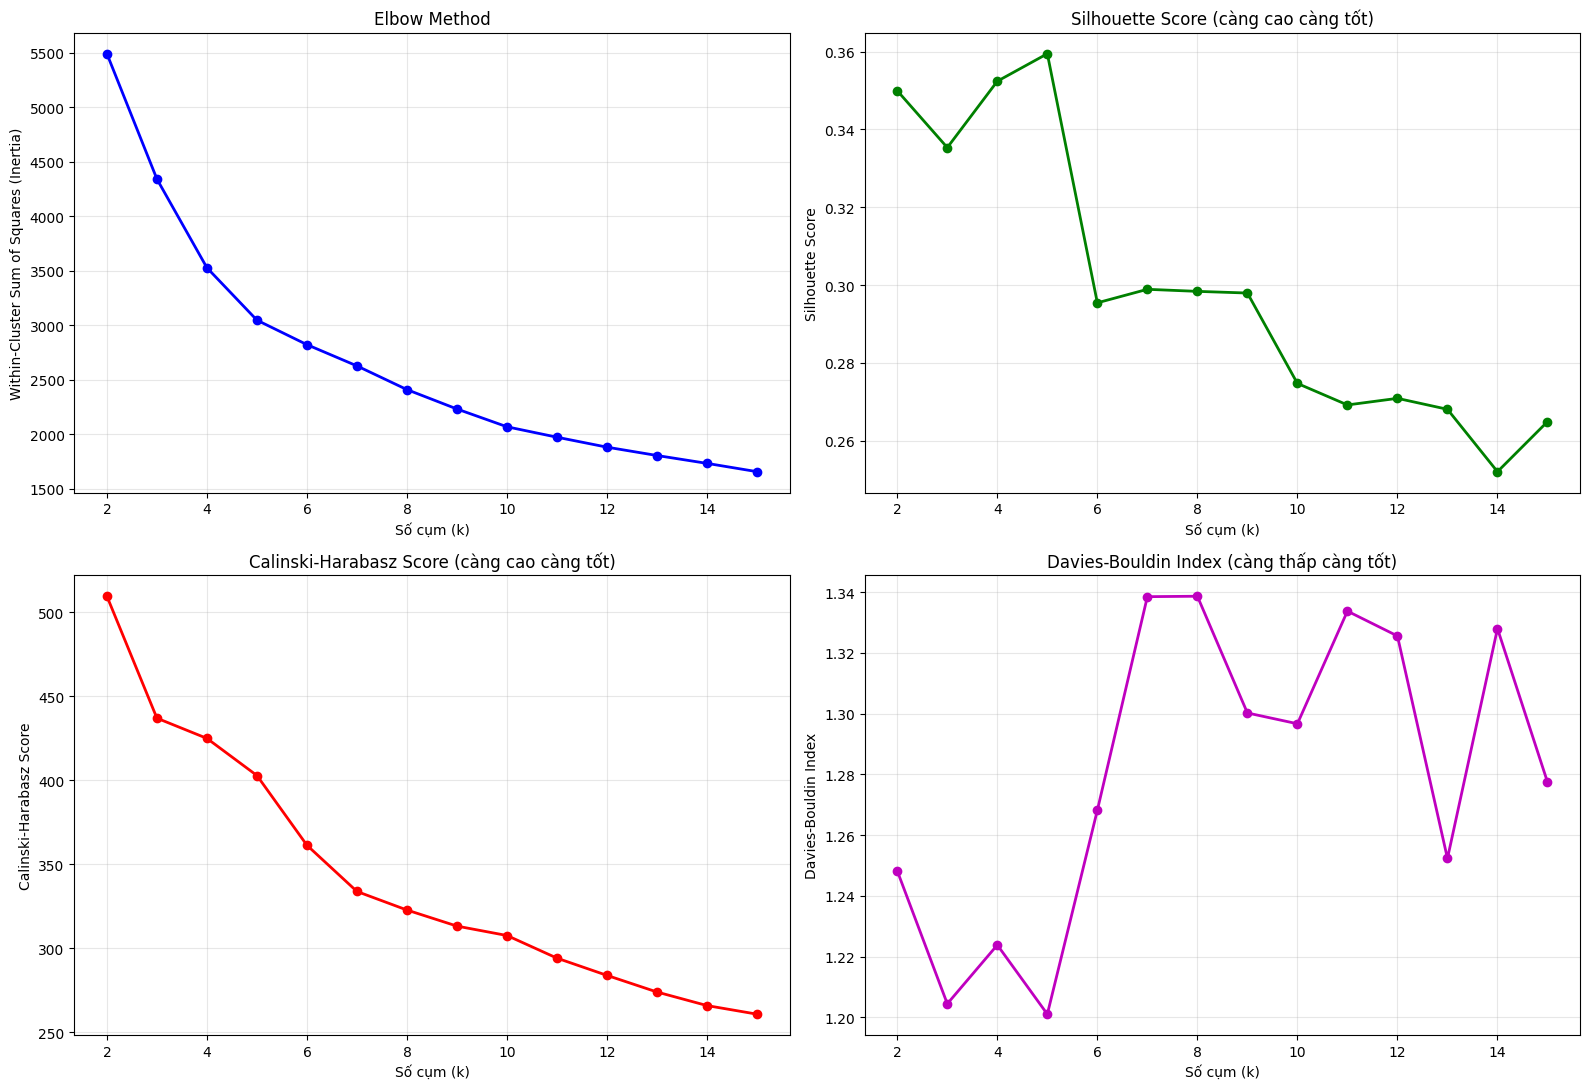


=== GỢI Ý SỐ CỤM TỐI ƯU ===
• Theo Silhouette Score     : k = 5 (score = 0.3595)
• Theo Calinski-Harabasz    : k = 2  (score = 509.44)
• Theo Davies-Bouldin       : k = 5  (score = 1.2011)

→ Khuyến nghị: Thường nên chọn k = 5 hoặc 2 kết hợp xem Elbow plot.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
inertia = []
sil_scores = []
ch_scores = []
db_scores = []
K_range = range(2, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k,
                    init='k-means++',
                    n_init=20,
                    random_state=42)
    kmeans.fit(X_train_scaled)

    inertia.append(kmeans.inertia_)
    labels = kmeans.labels_

    sil_scores.append(silhouette_score(X_train_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_train_scaled, labels))
    db_scores.append(davies_bouldin_score(X_train_scaled, labels))

# ====================== VẼ BIỂU ĐỒ ======================
fig, axs = plt.subplots(2, 2, figsize=(16, 11))

# 1. Elbow Method (Inertia)
axs[0,0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=6)
axs[0,0].set_xlabel('Số cụm (k)')
axs[0,0].set_ylabel('Within-Cluster Sum of Squares (Inertia)')
axs[0,0].set_title('Elbow Method')
axs[0,0].grid(True, alpha=0.3)

# 2. Silhouette Score
axs[0,1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=6)
axs[0,1].set_xlabel('Số cụm (k)')
axs[0,1].set_ylabel('Silhouette Score')
axs[0,1].set_title('Silhouette Score (càng cao càng tốt)')
axs[0,1].grid(True, alpha=0.3)

# 3. Calinski-Harabasz Score
axs[1,0].plot(K_range, ch_scores, 'ro-', linewidth=2, markersize=6)
axs[1,0].set_xlabel('Số cụm (k)')
axs[1,0].set_ylabel('Calinski-Harabasz Score')
axs[1,0].set_title('Calinski-Harabasz Score (càng cao càng tốt)')
axs[1,0].grid(True, alpha=0.3)

# 4. Davies-Bouldin Index
axs[1,1].plot(K_range, db_scores, 'mo-', linewidth=2, markersize=6)
axs[1,1].set_xlabel('Số cụm (k)')
axs[1,1].set_ylabel('Davies-Bouldin Index')
axs[1,1].set_title('Davies-Bouldin Index (càng thấp càng tốt)')
axs[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ====================== KẾT QUẢ TỐI ƯU ======================
best_k_sil = K_range[np.argmax(sil_scores)]
best_k_ch  = K_range[np.argmax(ch_scores)]
best_k_db  = K_range[np.argmin(db_scores)]

print(f"\n=== GỢI Ý SỐ CỤM TỐI ƯU ===")
print(f"• Theo Silhouette Score     : k = {best_k_sil} (score = {max(sil_scores):.4f})")
print(f"• Theo Calinski-Harabasz    : k = {best_k_ch}  (score = {max(ch_scores):.2f})")
print(f"• Theo Davies-Bouldin       : k = {best_k_db}  (score = {min(db_scores):.4f})")

# Gợi ý cuối cùng
print(f"\n→ Khuyến nghị: Thường nên chọn k = {best_k_sil} hoặc {best_k_ch} kết hợp xem Elbow plot.")

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=30)
X_train['cluster_kmeans'] = kmeans.fit_predict(X_train_scaled)

# Xem profile để xác nhận thứ tự cụm
cluster_profile = X_train.groupby('cluster_kmeans').mean().round(3)
display(cluster_profile)

,chasing_ratio,chasing_intensity,trade_accel_7d,trade_accel_30d,trade_accel_ratio,reaction_speed,reaction_rate,inconsistency_by_volume,inconsistency_by_event,drawdow_sensitivity
cluster_kmeans,,,,,,,,,,
0,0.530,2.289,90.770,56.092,0.044,17432.886,0.859,25.665,19.645,0.354
1,0.948,3.498,41.668,39.777,0.013,780.004,0.131,14.487,15.287,0.036
2,0.020,0.496,19.073,16.961,0.013,146.735,0.070,0.502,0.071,0.054


In [ ]:
def evaluate_clustering(X, labels, name="Model"):
    # Loại bỏ noise (-1) nếu có
    mask = labels != -1
    if len(set(labels[mask])) <= 1:
        print(f"{name}: Not enough clusters to evaluate.")
        return

    X_eval = X[mask]
    labels_eval = labels[mask]

    sil = silhouette_score(X_eval, labels_eval)
    dbi = davies_bouldin_score(X_eval, labels_eval)
    ch = calinski_harabasz_score(X_eval, labels_eval)

    print(f"=== {name} ===")
    print(f"Silhouette Score: {sil:.4f} (Gần 1 là tốt)")
    print(f"Davies-Bouldin Index: {dbi:.4f} (Càng thấp càng tốt)")
    print(f"Calinski-Harabasz Score: {ch:.2f} (Càng cao càng tốt)")

In [ ]:
evaluate_clustering(X_train_scaled, X_train["cluster_kmeans"], "Kmeans")

=== Kmeans ===
Silhouette Score: 0.3354 (Gần 1 là tốt)
Davies-Bouldin Index: 1.2045 (Càng thấp càng tốt)
Calinski-Harabasz Score: 436.86 (Càng cao càng tốt)


# DBSCAN

/tmp/ipykernel_3896/1378693399.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


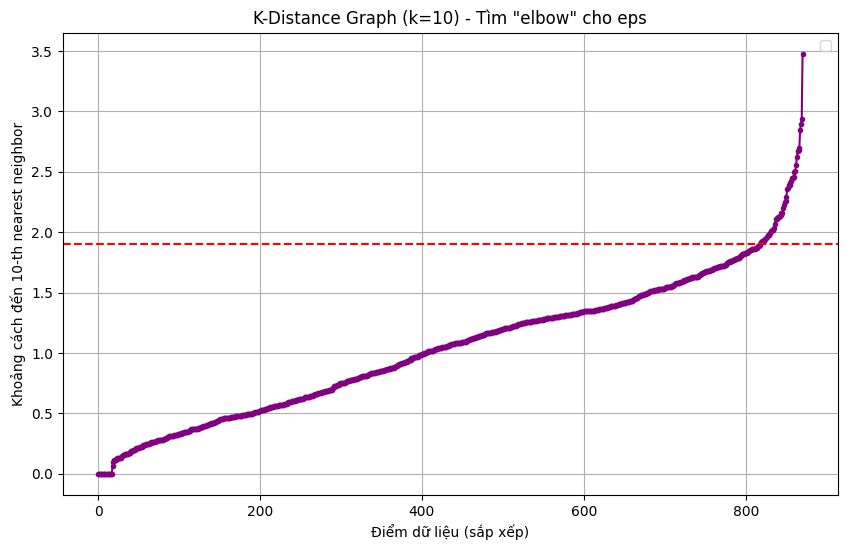

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k = 10

neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_train_scaled)
distances, _ = neighbors.kneighbors(X_train_scaled)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances, marker='.', color='purple')
plt.title(f'K-Distance Graph (k={k}) - Tìm "elbow" cho eps')
plt.xlabel('Điểm dữ liệu (sắp xếp)')
plt.ylabel(f'Khoảng cách đến {k}-th nearest neighbor')
plt.grid(True)

# Gợi ý eps (bạn nhìn elbow rồi chỉnh)
plt.axhline(y=1.9, color='red', linestyle='--')
plt.legend()
plt.show()

In [ ]:
%pip install optuna

In [ ]:
import optuna
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from hdbscan.validity import validity_index

def objective(trial):
    eps = trial.suggest_float('eps', 1.5, 2.2, step=0.05)        # dựa vào k-distance graph
    min_samples = trial.suggest_int('min_samples', 5, 30)

    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labels = db.fit_predict(X_train_scaled)

    # Xử lý trường hợp chỉ có 1 cluster hoặc toàn noise
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    if n_clusters < 2 or n_noise > 0.4 * len(labels):
        return -999.0

    # Ưu tiên dùng DBCV (Density-Based Cluster Validity) nếu có
    try:
        score = validity_index(X_train_scaled, labels)
    except:
        score = silhouette_score(X_train_scaled, labels)

    return score

# Chạy Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=150)   # thử 50-100 trials

print("Tham số tốt nhất:", study.best_params)
print("DBCV/Silhouette tốt nhất:", study.best_value)

[I 2026-04-14 19:45:31,777] A new study created in memory with name: no-name-66737c10-d068-4c85-9bbb-12ddb52f9f07
[I 2026-04-14 19:45:31,810] Trial 0 finished with value: -999.0 and parameters: {'eps': 2.15, 'min_samples': 30}. Best is trial 0 with value: -999.0.
[I 2026-04-14 19:45:32,137] Trial 1 finished with value: 0.1735657514342499 and parameters: {'eps': 1.8, 'min_samples': 6}. Best is trial 1 with value: 0.1735657514342499.
[I 2026-04-14 19:45:32,571] Trial 2 finished with value: 0.2044474245130021 and parameters: {'eps': 2.1, 'min_samples': 9}. Best is trial 2 with value: 0.2044474245130021.
[I 2026-04-14 19:45:32,797] Trial 3 finished with value: 0.34324519577700696 and parameters: {'eps': 1.65, 'min_samples': 30}. Best is trial 3 with value: 0.34324519577700696.
[I 2026-04-14 19:45:33,019] Trial 4 finished with value: 0.17268720021649825 and parameters: {'eps': 1.7, 'min_samples': 8}. Best is trial 3 with value: 0.34324519577700696.
[I 2026-04-14 19:45:33,321] Trial 5 finish

Tham số tốt nhất: {'eps': 1.55, 'min_samples': 30}
DBCV/Silhouette tốt nhất: 0.42223537649730586


In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.55, min_samples=30)
labels_db = db.fit_predict(X_train_scaled)

evaluate_clustering(X_train_scaled, labels_db, "DBSCAN")

=== DBSCAN ===
Silhouette Score: 0.5711 (Gần 1 là tốt)
Davies-Bouldin Index: 0.6581 (Càng thấp càng tốt)
Calinski-Harabasz Score: 834.31 (Càng cao càng tốt)


# HDBSCAN

In [ ]:
from hdbscan import HDBSCAN
import optuna
from hdbscan.validity import validity_index

def objective_hdbscan(trial):
    min_cluster_size = trial.suggest_int('min_cluster_size', 5, 80)
    min_samples = trial.suggest_int('min_samples', 2, min_cluster_size)
    cluster_selection_epsilon = trial.suggest_float('cluster_selection_epsilon', 0.0, 0.8)
    alpha = trial.suggest_float('alpha', 0.5, 2.0)

    model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_epsilon=cluster_selection_epsilon,
        alpha=alpha,
        metric='euclidean',
        gen_min_span_tree=True
    )
    labels = model.fit_predict(X_train_scaled)

    # Phạt penalty nếu lượng noise quá 30%
    n_noise = (labels == -1).sum()
    if n_noise > len(X_train_scaled) * 0.3:
        return -999.0

    # Đánh giá bằng DBCV trên X gốc
    if len(set(labels) - {-1}) > 1:
        score = validity_index(X_train_scaled, labels)
    else:
        score = -1.0

    return score

study_hdbscan = optuna.create_study(direction='maximize')
study_hdbscan.optimize(objective_hdbscan, n_trials=50)

print("Tham số tốt nhất:", study_hdbscan.best_params)

# Huấn luyện model HDBSCAN tốt nhất trên X
best_hdbscan = HDBSCAN(**study_hdbscan.best_params, gen_min_span_tree=True)
labels_hdbscan = best_hdbscan.fit_predict(X_train_scaled)

[I 2026-04-14 19:46:22,725] A new study created in memory with name: no-name-4e3a6d74-dcc3-4301-86ed-a66511602557
[I 2026-04-14 19:46:22,831] Trial 0 finished with value: -999.0 and parameters: {'min_cluster_size': 19, 'min_samples': 14, 'cluster_selection_epsilon': 0.37193775590301376, 'alpha': 1.1444425579328543}. Best is trial 0 with value: -999.0.
[I 2026-04-14 19:46:23,155] Trial 1 finished with value: 0.2007170552250644 and parameters: {'min_cluster_size': 75, 'min_samples': 33, 'cluster_selection_epsilon': 0.1165639726258137, 'alpha': 0.9763518098888209}. Best is trial 1 with value: 0.2007170552250644.
[I 2026-04-14 19:46:23,196] Trial 2 finished with value: -999.0 and parameters: {'min_cluster_size': 9, 'min_samples': 9, 'cluster_selection_epsilon': 0.04151328084022002, 'alpha': 1.6191284412781173}. Best is trial 1 with value: 0.2007170552250644.
[I 2026-04-14 19:46:23,382] Trial 3 finished with value: 0.12943466473266238 and parameters: {'min_cluster_size': 9, 'min_samples': 2

Tham số tốt nhất: {'min_cluster_size': 16, 'min_samples': 14, 'cluster_selection_epsilon': 0.6467633734853379, 'alpha': 1.0654477760127288}


In [ ]:
evaluate_clustering(X_train_scaled, labels_hdbscan, "hdbscan")

=== hdbscan ===
Silhouette Score: 0.4449 (Gần 1 là tốt)
Davies-Bouldin Index: 0.9528 (Càng thấp càng tốt)
Calinski-Harabasz Score: 463.97 (Càng cao càng tốt)


# GMM

In [ ]:
import optuna
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

def objective_gmm(trial):
    # Không gian siêu tham số
    n_components = 3
    covariance_type = trial.suggest_categorical('covariance_type', ['full', 'tied', 'diag', 'spherical'])

    gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, random_state=42)
    labels = gmm.fit_predict(X_train_scaled)

    # Đánh giá bằng Silhouette Score (phù hợp với GMM)
    if len(set(labels)) > 1:
        score = silhouette_score(X_train_scaled, labels)
    else:
        score = -1
    return score

# Khởi chạy Optuna cho GMM
study_gmm = optuna.create_study(direction='maximize')
study_gmm.optimize(objective_gmm, n_trials=50)

print("Tham số tốt nhất:", study_gmm.best_params)


[I 2026-04-14 19:58:30,925] A new study created in memory with name: no-name-2e82ee44-e04e-4db3-9fb5-f2604f4f25d4
[I 2026-04-14 19:58:31,102] Trial 0 finished with value: 0.3129070197969516 and parameters: {'covariance_type': 'tied'}. Best is trial 0 with value: 0.3129070197969516.
[I 2026-04-14 19:58:31,195] Trial 1 finished with value: 0.2735211280319419 and parameters: {'covariance_type': 'diag'}. Best is trial 0 with value: 0.3129070197969516.
[I 2026-04-14 19:58:31,338] Trial 2 finished with value: 0.3129070197969516 and parameters: {'covariance_type': 'tied'}. Best is trial 0 with value: 0.3129070197969516.
[I 2026-04-14 19:58:31,460] Trial 3 finished with value: 0.3129070197969516 and parameters: {'covariance_type': 'tied'}. Best is trial 0 with value: 0.3129070197969516.
[I 2026-04-14 19:58:31,569] Trial 4 finished with value: 0.28207945495338754 and parameters: {'covariance_type': 'spherical'}. Best is trial 0 with value: 0.3129070197969516.
[I 2026-04-14 19:58:31,685] Trial 5

Tham số tốt nhất: {'covariance_type': 'tied'}


In [ ]:
# Áp dụng tham số tốt nhất để lấy nhãn phân cụm
best_gmm = GaussianMixture(n_components=3, covariance_type='tied', random_state=42)
labels_gmm = best_gmm.fit_predict(X_train_scaled)
evaluate_clustering(X_train_scaled, labels_gmm, "GMM")

=== GMM ===
Silhouette Score: 0.3129 (Gần 1 là tốt)
Davies-Bouldin Index: 1.2040 (Càng thấp càng tốt)
Calinski-Harabasz Score: 383.25 (Càng cao càng tốt)


In [ ]:
labels_kmeans = X_train['cluster_kmeans'].values

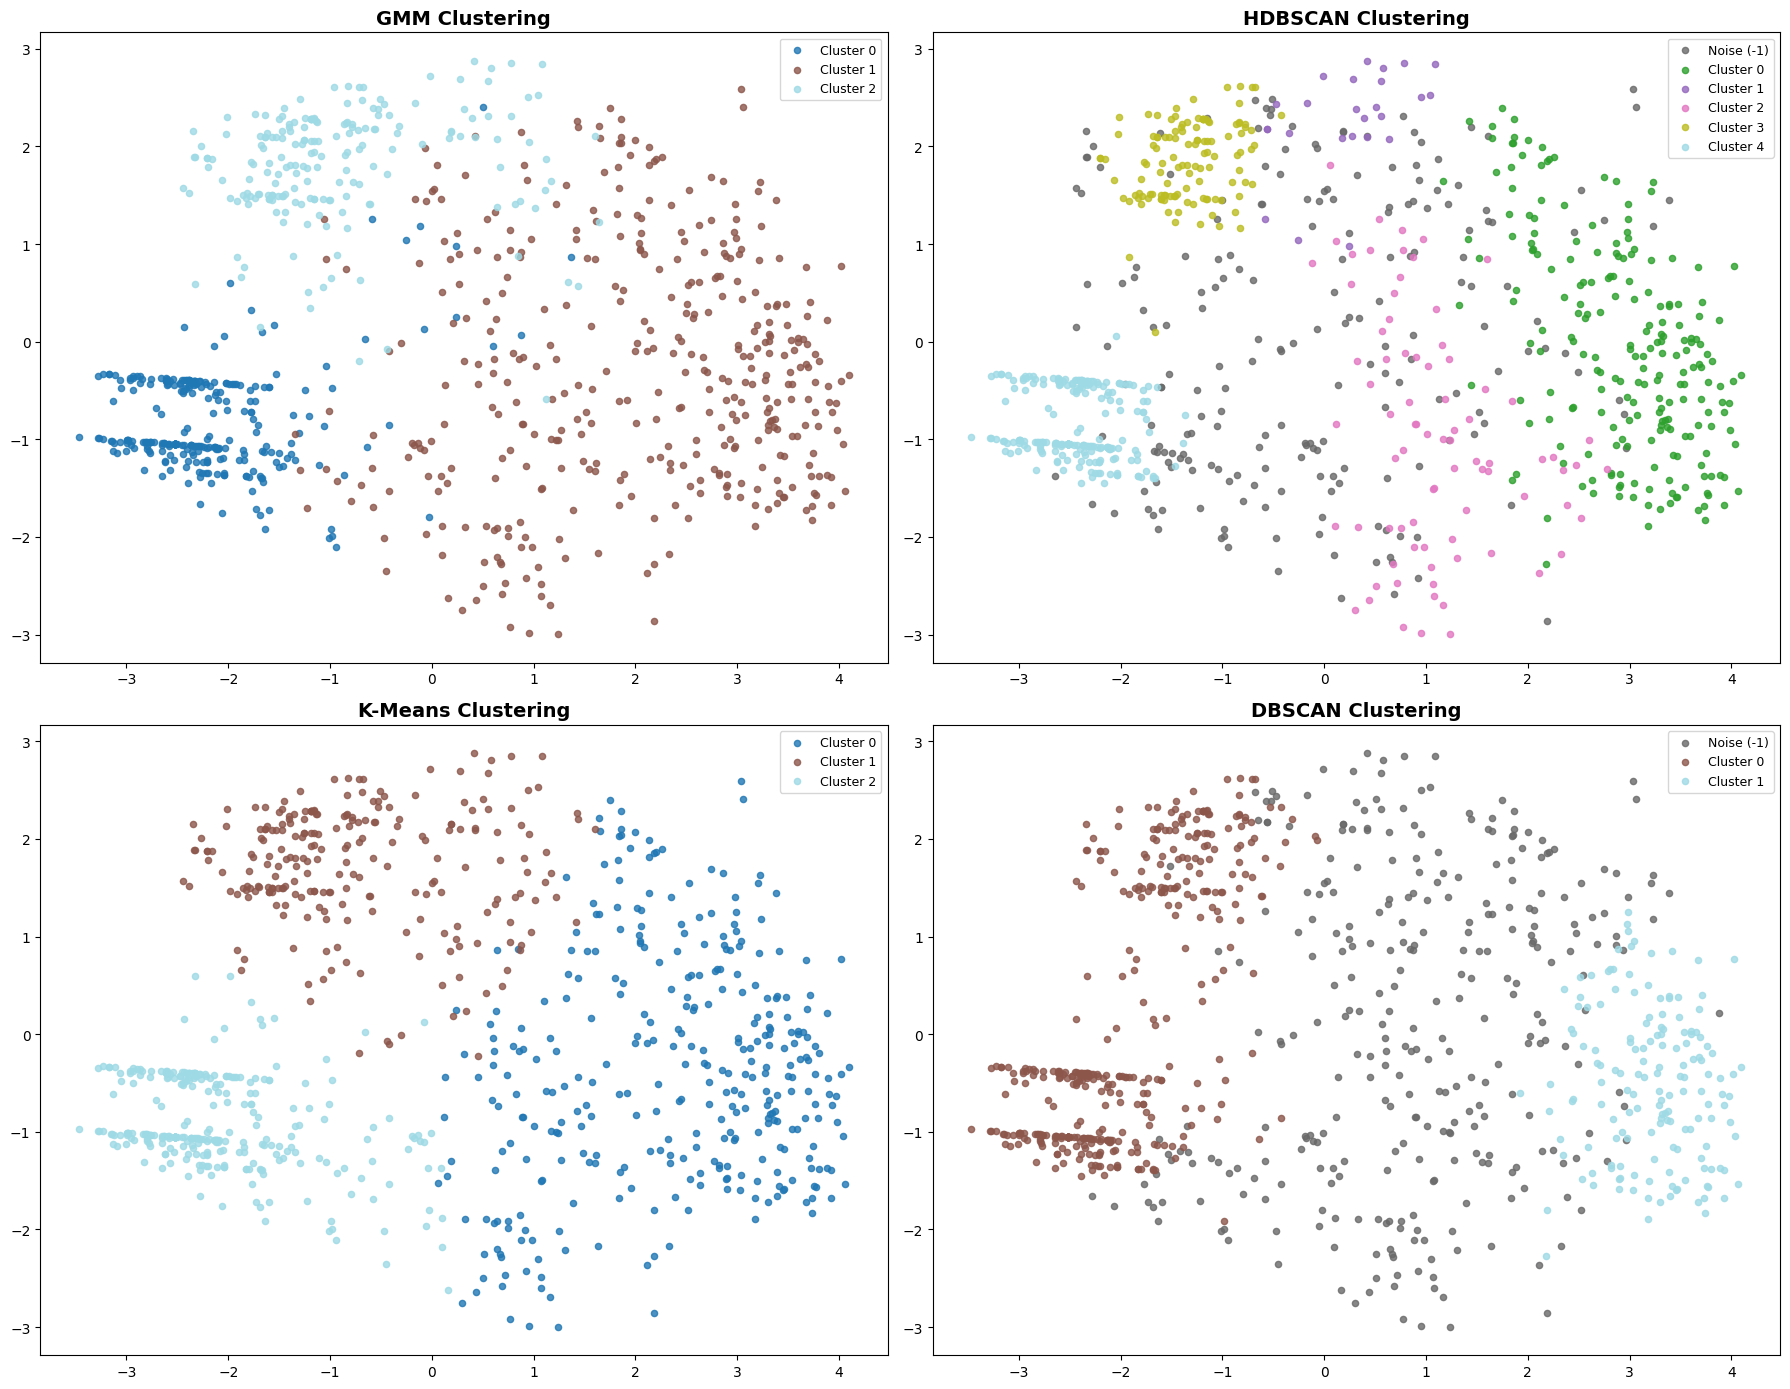

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)
fig, axs = plt.subplots(2, 2, figsize=(18, 14))
(ax1, ax2), (ax3, ax4) = axs

unique_labels_gmm = np.unique(labels_gmm)
colors_gmm = plt.cm.tab20(np.linspace(0, 1, len(unique_labels_gmm)))

for i, label in enumerate(unique_labels_gmm):
    mask = labels_gmm == label
    color = 'dimgray' if label == -1 else colors_gmm[i]
    label_name = 'Noise (-1)' if label == -1 else f'Cluster {label}'
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=label_name, s=20, alpha=0.8)

ax1.set_title("GMM Clustering", fontsize=14, fontweight='bold')
if len(unique_labels_gmm) <= 15:
    ax1.legend(loc='best', fontsize=9)

unique_labels_hdb = np.unique(labels_hdbscan)
colors_hdb = plt.cm.tab20(np.linspace(0, 1, len(unique_labels_hdb)))

for i, label in enumerate(unique_labels_hdb):
    mask = labels_hdbscan == label
    color = 'dimgray' if label == -1 else colors_hdb[i]
    label_name = 'Noise (-1)' if label == -1 else f'Cluster {label}'
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=label_name, s=20, alpha=0.8)

ax2.set_title("HDBSCAN Clustering", fontsize=14, fontweight='bold')
if len(unique_labels_hdb) <= 15:
    ax2.legend(loc='best', fontsize=9)

unique_labels_kmeans = np.unique(labels_kmeans)
colors_kmeans = plt.cm.tab20(np.linspace(0, 1, len(unique_labels_kmeans)))

for i, label in enumerate(unique_labels_kmeans):
    mask = labels_kmeans == label
    color = 'dimgray' if label == -1 else colors_kmeans[i]
    label_name = 'Noise (-1)' if label == -1 else f'Cluster {label}'
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=label_name, s=20, alpha=0.8)

ax3.set_title("K-Means Clustering", fontsize=14, fontweight='bold')
if len(unique_labels_kmeans) <= 15:
    ax3.legend(loc='best', fontsize=9)

unique_labels_db = np.unique(labels_db)
colors_db = plt.cm.tab20(np.linspace(0, 1, len(unique_labels_db)))

for i, label in enumerate(unique_labels_db):
    mask = labels_db == label
    color = 'dimgray' if label == -1 else colors_db[i]
    label_name = 'Noise (-1)' if label == -1 else f'Cluster {label}'
    ax4.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=label_name, s=20, alpha=0.8)

ax4.set_title("DBSCAN Clustering", fontsize=14, fontweight='bold')
if len(unique_labels_db) <= 15:
    ax4.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from IPython.display import display

df_analysis = X_train.drop(columns=['cluster_kmeans']).copy()

df_analysis['Cluster_KMeans'] = labels_kmeans
df_analysis['Cluster_GMM'] = labels_gmm
df_analysis['Cluster_HDBSCAN'] = labels_hdbscan
df_analysis['Cluster_DBSCAN'] = labels_db

kmeans_profile = df_analysis.drop(columns=['Cluster_GMM', 'Cluster_HDBSCAN', 'Cluster_DBSCAN']).groupby('Cluster_KMeans').mean()
kmeans_profile.insert(0, 'So_luong_User', df_analysis.groupby('Cluster_KMeans').size())
display(kmeans_profile)

gmm_profile = df_analysis.drop(columns=['Cluster_KMeans', 'Cluster_HDBSCAN', 'Cluster_DBSCAN']).groupby('Cluster_GMM').mean()
gmm_profile.insert(0, 'So_luong_User', df_analysis.groupby('Cluster_GMM').size())
display(gmm_profile)

hdbscan_profile = df_analysis.drop(columns=['Cluster_KMeans', 'Cluster_GMM', 'Cluster_DBSCAN']).groupby('Cluster_HDBSCAN').mean()
hdbscan_profile.insert(0, 'So_luong_User', df_analysis.groupby('Cluster_HDBSCAN').size())
display(hdbscan_profile)

dbscan_profile = df_analysis.drop(columns=['Cluster_KMeans', 'Cluster_GMM', 'Cluster_HDBSCAN']).groupby('Cluster_DBSCAN').mean()
dbscan_profile.insert(0, 'So_luong_User', df_analysis.groupby('Cluster_DBSCAN').size())
display(dbscan_profile)

,So_luong_User,chasing_ratio,chasing_intensity,trade_accel_7d,trade_accel_30d,trade_accel_ratio,reaction_speed,reaction_rate,inconsistency_by_volume,inconsistency_by_event,drawdow_sensitivity,fomo_level
Cluster_KMeans,,,,,,,,,,,,
0,337,0.530045,2.288761,90.770179,56.091830,0.044267,17432.885806,0.858643,25.665386,19.645197,0.353751,1.0
1,235,0.947585,3.498043,41.667910,39.776511,0.012673,780.003546,0.130671,14.487318,15.287256,0.035506,2.0
2,299,0.020110,0.495520,19.073362,16.960912,0.013316,146.734615,0.069825,0.501672,0.070606,0.054190,0.0


,So_luong_User,chasing_ratio,chasing_intensity,trade_accel_7d,trade_accel_30d,trade_accel_ratio,reaction_speed,reaction_rate,inconsistency_by_volume,inconsistency_by_event,drawdow_sensitivity,fomo_level
Cluster_GMM,,,,,,,,,,,,
0,279,0.031719,0.513535,16.682445,14.820544,0.013320,1.882109,0.001249,2.704493,1.418900,0.058016,0.050179
1,397,0.535984,2.355384,85.472975,55.206289,0.039524,15369.097964,0.857933,20.688987,16.188603,0.294351,1.037783
2,195,0.952232,3.400765,38.447544,37.281595,0.012668,0.000000,0.000000,16.593197,17.493844,0.054961,1.953846


,So_luong_User,chasing_ratio,chasing_intensity,trade_accel_7d,trade_accel_30d,trade_accel_ratio,reaction_speed,reaction_rate,inconsistency_by_volume,inconsistency_by_event,drawdow_sensitivity,fomo_level
Cluster_HDBSCAN,,,,,,,,,,,,
-1,208,0.481867,2.069419,97.036279,85.737961,0.019898,4811.179647,0.389687,13.562144,12.265083,0.195497,1.004808
0,215,0.600102,2.573220,75.944956,34.916156,0.048678,11795.993721,0.893630,34.932151,26.494158,0.355904,1.009302
1,25,0.941176,3.080254,28.294225,28.473280,0.011791,0.000000,0.000000,74.896655,79.466667,0.000000,2.000000
2,81,0.435495,1.921038,50.135261,32.684323,0.036725,31669.049177,0.836576,0.000000,0.000000,0.328125,1.148148
3,120,0.990104,3.593048,19.777152,19.131575,0.011324,0.000000,0.000000,0.000000,0.000000,0.000000,1.983333
4,222,0.002041,0.423672,10.951184,10.478463,0.011912,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,So_luong_User,chasing_ratio,chasing_intensity,trade_accel_7d,trade_accel_30d,trade_accel_ratio,reaction_speed,reaction_rate,inconsistency_by_volume,inconsistency_by_event,drawdow_sensitivity,fomo_level
Cluster_DBSCAN,,,,,,,,,,,,
-1,313,0.568896,2.382974,74.741816,63.080049,0.023881,11929.206150,0.618990,23.109971,23.156880,0.259712,1.124601
0,401,0.370671,1.616102,20.118210,18.980966,0.012679,0.060204,0.004194,0.000000,0.000000,0.000127,0.743142
1,157,0.513483,2.213918,93.139196,38.002019,0.059353,15084.021231,0.926894,31.658178,19.018754,0.397581,1.000000


#Gán nhãn

In [ ]:
# Tính giá trị trung bình của tất cả đặc trưng theo từng cụm
cluster_profile = X_train.groupby('cluster_kmeans').mean()

# Hiển thị bảng này để bạn nhìn tận mắt
print("--- Bảng đặc trưng trung bình của từng cụm ---")
display(cluster_profile)

--- Bảng đặc trưng trung bình của từng cụm ---


,chasing_ratio,chasing_intensity,trade_accel_7d,trade_accel_30d,trade_accel_ratio,reaction_speed,reaction_rate,inconsistency_by_volume,inconsistency_by_event,drawdow_sensitivity
cluster_kmeans,,,,,,,,,,
0,0.530045,2.288761,90.770179,56.091830,0.044267,17432.885806,0.858643,25.665386,19.645197,0.353751
1,0.947585,3.498043,41.667910,39.776511,0.012673,780.003546,0.130671,14.487318,15.287256,0.035506
2,0.020110,0.495520,19.073362,16.960912,0.013316,146.734615,0.069825,0.501672,0.070606,0.054190


In [ ]:
# ====================== 4. GÁN NHÃN 0,1,2 (theo profile) ======================
# Bạn kiểm tra bảng profile ở trên rồi chỉnh mapping nếu cần
# Hiện tại dùng mapping cũ của bạn:
label_map = {
    2: 0,   # Cụm 2 → Không FOMO (thấp nhất)
    0: 1,   # Cụm 0 → FOMO cao
    1: 2    # Cụm 1 → FOMO tb
}

X_train['fomo_level'] = X_train['cluster_kmeans'].map(label_map)

print("Phân bố nhãn trên train:")
print(X_train['fomo_level'].value_counts().sort_index())

Phân bố nhãn trên train:
fomo_level
0    299
1    337
2    235
Name: count, dtype: int64


In [ ]:
X_test['cluster_kmeans'] = kmeans.predict(X_test_scaled)
X_test['fomo_level']     = X_test['cluster_kmeans'].map(label_map)

print("Phân bố nhãn trên test:")
print(X_test['fomo_level'].value_counts().sort_index())

Phân bố nhãn trên test:
fomo_level
0    207
1    215
2    159
Name: count, dtype: int64


#Xây dựng mô hình phân loại

## XGBoost

In [ ]:

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

X_train_final = X_train_scaled
y_train = X_train['fomo_level'].values

X_test_final = X_test_scaled
y_test = X_test['fomo_level'].values

xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
)
xgb_model.fit(X_train_final, y_train)

# Dự đoán
y_pred = xgb_model.predict(X_test_final)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report XGBoost:")
print(classification_report(y_test, y_pred,
      target_names=['0 - Không FOMO', '1 - FOMO Cao', '2 - FOMO Trung bình']))
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9673

Classification Report XGBoost:
                     precision    recall  f1-score   support

     0 - Không FOMO       0.97      0.97      0.97       207
       1 - FOMO Cao       0.96      0.97      0.97       215
2 - FOMO Trung bình       0.97      0.96      0.96       159

           accuracy                           0.97       581
          macro avg       0.97      0.97      0.97       581
       weighted avg       0.97      0.97      0.97       581

[[201   2   4]
 [  5 209   1]
 [  1   6 152]]


## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Huấn luyện
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_final, y_train)

# Dự đoán
y_pred_dt = dt_model.predict(X_test_final)

print("--- KẾT QUẢ DECISION TREE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

--- KẾT QUẢ DECISION TREE ---
Accuracy: 0.9501
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       207
           1       0.93      0.96      0.94       215
           2       0.94      0.91      0.92       159

    accuracy                           0.95       581
   macro avg       0.95      0.95      0.95       581
weighted avg       0.95      0.95      0.95       581



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=4)
rf_model.fit(X_train_final, y_train)

# BƯỚC 3: Dự đoán và in kết quả
y_pred = rf_model.predict(X_test_final)

print("--- KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred, target_names=['Không FOMO', 'FOMO Trung bình', 'FOMO Cao']))

--- KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST ---
Accuracy: 0.9725

Báo cáo chi tiết:
                 precision    recall  f1-score   support

     Không FOMO       0.98      0.98      0.98       207
FOMO Trung bình       0.96      0.97      0.97       215
       FOMO Cao       0.98      0.96      0.97       159

       accuracy                           0.97       581
      macro avg       0.97      0.97      0.97       581
   weighted avg       0.97      0.97      0.97       581



In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

#Decision tree
start = time.time()

dt_params = {
    'max_depth': [3, 5, 6, 7, 8, 10],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 4, 5, 8, 10],
    'criterion': ['gini', 'entropy']
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=30,                    # thử 30 tổ hợp ngẫu nhiên
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

dt_search.fit(X_train_final, y_train)

print(f"Thời gian tuning DT: {time.time() - start:.2f} giây")
print(f"Best params DT: {dt_search.best_params_}")
print(f"Best CV score DT: {dt_search.best_score_:.4f}")

best_dt = dt_search.best_estimator_
y_pred_dt = best_dt.predict(X_test_final)
print(f"Test Accuracy DT: {accuracy_score(y_test, y_pred_dt):.4f}\n")


#Random Forest
start = time.time()

rf_params = {
    'n_estimators': [80, 100, 150, 200, 250],
    'max_depth': [6, 8, 10, 12, 15],
    'min_samples_split': [4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=40,                    # thử 40 tổ hợp
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train_final, y_train)

print(f"Thời gian tuning RF: {time.time() - start:.2f} giây")
print(f"Best params RF: {rf_search.best_params_}")
print(f"Best CV score RF: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_final)
print(f"Test Accuracy RF: {accuracy_score(y_test, y_pred_rf):.4f}\n")

#XGBoost
start = time.time()

xgb_params = {
    'n_estimators': [100, 150, 200, 250],
    'learning_rate': [0.01, 0.05, 0.08, 0.1, 0.15],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    param_distributions=xgb_params,
    n_iter=50,                    # thử 50 tổ hợp (XGBoost nhiều tham số hơn)
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train_final, y_train)

print(f"Thời gian tuning XGB: {time.time() - start:.2f} giây")
print(f"Best params XGB: {xgb_search.best_params_}")
print(f"Best CV score XGB: {xgb_search.best_score_:.4f}")

best_xgb = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_final)
print(f"Test Accuracy XGB: {accuracy_score(y_test, y_pred_xgb):.4f}\n")


# ====================== BÁO CÁO CUỐI ======================
print("=== KẾT QUẢ TỔNG HỢP ===")
print(f"Decision Tree : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"XGBoost       : {accuracy_score(y_test, y_pred_xgb):.4f}")

print("\nBáo cáo chi tiết XGBoost (mô hình tốt nhất thường là RF hoặc XGB):")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Không FOMO', 'FOMO Trung bình', 'FOMO Cao']))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Thời gian tuning DT: 10.82 giây
Best params DT: {'min_samples_split': 15, 'min_samples_leaf': 4, 'max_depth': 8, 'criterion': 'entropy'}
Best CV score DT: 0.9678
Test Accuracy DT: 0.9312

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Thời gian tuning RF: 111.87 giây
Best params RF: {'n_estimators': 200, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8, 'bootstrap': False}
Best CV score RF: 0.9724
Test Accuracy RF: 0.9776

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Thời gian tuning XGB: 48.82 giây
Best params XGB: {'subsample': 0.8, 'n_estimators': 150, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Best CV score XGB: 0.9816
Test Accuracy XGB: 0.9707

=== KẾT QUẢ TỔNG HỢP ===
Decision Tree : 0.9312
Random Forest : 0.9776
XGBoost       : 0.9707

Báo cáo chi tiết XGBoost (mô hình tốt nhất thường là RF hoặc XGB):
      

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:49:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
#Random Forest
print(classification_report(y_test, y_pred_rf,
      target_names=['Không FOMO', 'FOMO Trung bình', 'FOMO Cao']))

                 precision    recall  f1-score   support

     Không FOMO       0.98      0.98      0.98       207
FOMO Trung bình       0.98      0.98      0.98       215
       FOMO Cao       0.97      0.97      0.97       159

       accuracy                           0.98       581
      macro avg       0.98      0.98      0.98       581
   weighted avg       0.98      0.98      0.98       581



In [ ]:
#Decesion
print(classification_report(y_test, y_pred_dt,
      target_names=['Không FOMO', 'FOMO Trung bình', 'FOMO Cao']))

                 precision    recall  f1-score   support

     Không FOMO       0.96      0.93      0.94       207
FOMO Trung bình       0.92      0.92      0.92       215
       FOMO Cao       0.92      0.95      0.93       159

       accuracy                           0.93       581
      macro avg       0.93      0.93      0.93       581
   weighted avg       0.93      0.93      0.93       581



In [ ]:
# Xem profile của nhóm FOMO cao
fomo_cao_profile = X_train[X_train['fomo_level'] == 2].mean(numeric_only=True)
print(fomo_cao_profile)

chasing_ratio                0.947585
chasing_intensity            3.498043
trade_accel_7d              41.667910
trade_accel_30d             39.776511
trade_accel_ratio            0.012673
reaction_speed             780.003546
reaction_rate                0.130671
inconsistency_by_volume     14.487318
inconsistency_by_event      15.287256
drawdow_sensitivity          0.035506
cluster_kmeans               1.000000
fomo_level                   2.000000
dtype: float64
